# Tweeting Fear: Trump Tweets × Market Volatility
### BUSN 20800 Big Data — Proposal Notebook
**Hewitt Watkins, Erik Lopez, Mateo Fretes, Vedant Dangayach**

This notebook produces all summary statistics and regressions needed for the project proposal.

**To run:** upload `trump_tweets_dataset.csv` to your Colab session (or set `TWEETS_PATH` below), add your FRED API key, then `Runtime → Run All`.


## 0. Install & Import

In [1]:
# Run once in Colab
!pip install vaderSentiment fredapi yfinance statsmodels -q


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings, re
warnings.filterwarnings('ignore')

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import statsmodels.api as sm
from scipy import stats

# ── Plotting style ──
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 130, "axes.titlesize": 12, "axes.labelsize": 10})
print("Imports OK")


Imports OK


## 1. Configuration — set your paths & API key here

In [3]:
# ── USER SETTINGS ─────────────────────────────────────────────────────────
TWEETS_PATH = "trump_tweets_dataset.csv"   # path to the uploaded CSV
FRED_API_KEY = "YOUR_FRED_API_KEY_HERE"    # paste your FRED key here

# Date window: Trump Twitter first term
START = "2017-01-20"
END   = "2021-01-20"
# ──────────────────────────────────────────────────────────────────────────


## 2. Load & Clean Tweets

In [4]:
df = pd.read_csv(TWEETS_PATH)
print(f"Raw rows: {len(df):,}")

# Parse dates
df['date'] = pd.to_datetime(df['date'], utc=True, errors='coerce')
df = df.dropna(subset=['date', 'text'])

# Keep only Twitter, original posts (no reposts / quotes), first term
df = df[
    (df['platform'] == 'Twitter') &
    (df['repost_flag'] == False) &
    (df['quote_flag']  == False) &
    (df['date'] >= START) &
    (df['date'] <= END)
].copy()

df = df.sort_values('date').reset_index(drop=True)
print(f"After filtering (Twitter, original, 2017-2021): {len(df):,} tweets")
print(df[['date','text','favorite_count','repost_count']].head(3).to_string())


Raw rows: 90,554
After filtering (Twitter, original, 2017-2021): 16,491 tweets
                       date                                                                                                                                                              text  favorite_count  repost_count
0 2017-01-20 00:40:51+00:00  Thank you for joining us at the Lincoln Memorial tonight- a very special evening! Together, we are going to MAKE AMERICA GREAT AGAIN! pic.twitter.com/5d774OCx5o          146346         28852
1 2017-01-20 04:24:33+00:00                                                                    Thank you for a wonderful evening in Washington, D.C. #Inauguration pic.twitter.com/a6xpFQTHj5           98164         17221
2 2017-01-20 12:31:53+00:00                                                  It all begins today! I will see you at 11:00 A.M. for the swearing-in. THE MOVEMENT CONTINUES - THE WORK BEGINS!          234807         58312


## 3. Feature Engineering

In [5]:
analyzer = SentimentIntensityAnalyzer()

print("Running VADER (this takes ~30 seconds)...")
scores = df['text'].apply(lambda t: analyzer.polarity_scores(str(t)))
df['vader_compound'] = scores.apply(lambda s: s['compound'])
df['vader_pos']      = scores.apply(lambda s: s['pos'])
df['vader_neg']      = scores.apply(lambda s: s['neg'])
df['vader_neu']      = scores.apply(lambda s: s['neu'])

# Stylometric features
df['tweet_len']     = df['text'].str.len()
df['exclamations']  = df['text'].str.count('!')
df['questions']     = df['text'].str.count(r'\?')
df['caps_words']    = df['text'].apply(
    lambda t: sum(1 for w in str(t).split() if w.isupper() and len(w) > 1))
df['frac_caps']     = df['caps_words'] / (df['word_count'].replace(0, np.nan))
df['has_url']       = df['urls'].notna().astype(int)
df['n_mentions']    = df['user_mentions'].fillna('').str.count('@')
df['n_hashtags']    = df['hashtags'].fillna('').str.count('#')

# Engagement (fill NaN with 0)
df['favorite_count'] = pd.to_numeric(df['favorite_count'], errors='coerce').fillna(0)
df['repost_count']   = pd.to_numeric(df['repost_count'],   errors='coerce').fillna(0)

print("Features computed. Sample:")
feat_cols = ['date','vader_compound','frac_caps','exclamations','tweet_len']
print(df[feat_cols].head(3).to_string())


Running VADER (this takes ~30 seconds)...
Features computed. Sample:
                       date  vader_compound  frac_caps  exclamations  tweet_len
0 2017-01-20 00:40:51+00:00          0.8981   0.166667             2        160
1 2017-01-20 04:24:33+00:00          0.7351   0.090909             0         94
2 2017-01-20 12:31:53+00:00          0.0000   0.333333             2        112


## 4. Aggregate to Weekly Level (Saturday → Friday)

In [6]:
# Assign each tweet to its Friday week-end
df['week_end'] = (
    df['date']
    .dt.to_period('W-FRI')
    .apply(lambda p: p.end_time)
    .dt.tz_localize(None)
    .dt.normalize()
)

weekly = df.groupby('week_end').agg(
    tweet_count      = ('text',          'count'),
    mean_vader       = ('vader_compound','mean'),
    std_vader        = ('vader_compound','std'),
    mean_vader_neg   = ('vader_neg',     'mean'),
    mean_vader_pos   = ('vader_pos',     'mean'),
    frac_negative    = ('vader_compound', lambda x: (x < -0.05).mean()),
    frac_positive    = ('vader_compound', lambda x: (x >  0.05).mean()),
    mean_frac_caps   = ('frac_caps',     'mean'),
    mean_exclamation = ('exclamations',  'mean'),
    mean_tweet_len   = ('tweet_len',     'mean'),
    mean_retweets    = ('repost_count',  'mean'),
    mean_favorites   = ('favorite_count','mean'),
    n_hashtags       = ('n_hashtags',    'mean'),
).reset_index()

weekly['week_end'] = pd.to_datetime(weekly['week_end'])
print(f"Weekly observations: {len(weekly)}")
print(weekly.head(3).to_string())


Weekly observations: 208
    week_end  tweet_count  mean_vader  std_vader  mean_vader_neg  mean_vader_pos  frac_negative  frac_positive  mean_frac_caps  mean_exclamation  mean_tweet_len  mean_retweets  mean_favorites  n_hashtags
0 2017-01-20           13    0.185008   0.406938        0.024538        0.102615       0.076923       0.461538        0.140693          0.461538       114.00000   26992.846154   126011.076923    0.384615
1 2017-01-27           40    0.274702   0.519306        0.058375        0.179825       0.200000       0.700000        0.054498          0.675000       128.00000   21586.975000   114810.350000    0.075000
2 2017-02-03           41   -0.105068   0.635684        0.153439        0.143146       0.536585       0.390244        0.049019          0.707317       125.95122   24468.195122   120446.463415    0.024390


## 5. Pull VIX and EPU from FRED

In [8]:
from fredapi import Fred
fred = Fred(api_key='beeed973495d94c208c342e754c75413')

# ── VIX ──
vix_raw = fred.get_series('VIXCLS', observation_start=START, observation_end=END)
vix_raw = vix_raw.dropna().reset_index()
vix_raw.columns = ['date', 'vix']
vix_raw['date'] = pd.to_datetime(vix_raw['date'])

# Weekly Friday close
vix_w = (vix_raw
         .set_index('date')
         .resample('W-FRI').last()
         .reset_index())
vix_w.columns = ['week_end', 'vix']
vix_w['vix_lag1']       = vix_w['vix'].shift(1)
vix_w['delta_vix']      = vix_w['vix'] - vix_w['vix_lag1']          # this week's change
vix_w['delta_vix_next'] = vix_w['delta_vix'].shift(-1)               # TARGET: next week

print(f"VIX weekly obs: {len(vix_w)}")
print(vix_w.head(3).to_string())


VIX weekly obs: 210
    week_end    vix  vix_lag1  delta_vix  delta_vix_next
0 2017-01-20  11.54       NaN        NaN           -0.96
1 2017-01-27  10.58     11.54      -0.96            0.39
2 2017-02-03  10.97     10.58       0.39           -0.12


In [9]:
# ── EPU (Baker Bloom Davis — monthly, forward-filled to weekly) ──
epu_raw = fred.get_series('USEPUINDXM', observation_start=START, observation_end=END)
epu_raw = epu_raw.dropna().reset_index()
epu_raw.columns = ['date', 'epu']
epu_raw['date'] = pd.to_datetime(epu_raw['date'])

epu_w = (epu_raw
         .set_index('date')
         .resample('W-FRI').ffill()
         .reset_index())
epu_w.columns = ['week_end', 'epu']
epu_w['delta_epu'] = epu_w['epu'].diff()

print(f"EPU weekly obs (forward-filled from monthly): {len(epu_w)}")

# ── Optional macro controls from FRED ──
macro_series = {
    'fedfunds':  'FEDFUNDS',      # Federal Funds Rate
    'unrate':    'UNRATE',        # Unemployment Rate
    'sp500':     'SP500',         # S&P 500 level
}

macro_dfs = []
for name, series_id in macro_series.items():
    try:
        s = fred.get_series(series_id, observation_start=START, observation_end=END)
        s = s.dropna().reset_index()
        s.columns = ['date', name]
        s['date'] = pd.to_datetime(s['date'])
        s = s.set_index('date').resample('W-FRI').ffill().reset_index()
        s.columns = ['week_end', name]
        macro_dfs.append(s)
        print(f"  Loaded {series_id}: {len(s)} weekly obs")
    except Exception as e:
        print(f"  Could not load {series_id}: {e}")


EPU weekly obs (forward-filled from monthly): 209
  Loaded FEDFUNDS: 209 weekly obs
  Loaded UNRATE: 209 weekly obs
  Loaded SP500: 210 weekly obs


## 6. Merge into Master Dataset

In [10]:
master = (weekly
          .merge(vix_w,  on='week_end', how='inner')
          .merge(epu_w,  on='week_end', how='left'))

for mdf in macro_dfs:
    master = master.merge(mdf, on='week_end', how='left')

master = master.sort_values('week_end').reset_index(drop=True)

# Forward-fill monthly macro series
for col in ['fedfunds', 'unrate', 'epu']:
    if col in master.columns:
        master[col] = master[col].ffill()

# S&P weekly return
if 'sp500' in master.columns:
    master['sp500_ret'] = master['sp500'].pct_change()

print(f"Master dataset: {len(master)} weeks  x  {master.shape[1]} columns")
print(master[['week_end','tweet_count','mean_vader','vix','delta_vix_next']].head(5).to_string())


Master dataset: 208 weeks  x  24 columns
    week_end  tweet_count  mean_vader    vix  delta_vix_next
0 2017-01-20           13    0.185008  11.54           -0.96
1 2017-01-27           40    0.274702  10.58            0.39
2 2017-02-03           41   -0.105068  10.97           -0.12
3 2017-02-10           48   -0.042546  10.85            0.64
4 2017-02-17           50    0.078734  11.49           -0.02


## 7. Summary Statistics (Tables A & B for Proposal)

In [11]:
# ── Table A: Tweet features ──
tweet_feat_cols = {
    'tweet_count':      'Weekly Tweet Count',
    'mean_vader':       'Mean VADER Compound',
    'mean_retweets':    'Mean Retweets',
    'mean_tweet_len':   'Mean Tweet Length (chars)',
    'mean_frac_caps':   'Frac. All-Caps Words',
    'mean_exclamation': 'Mean Exclamations per Tweet',
    'frac_negative':    'Frac. Negative Tweets (VADER < -0.05)',
}

table_a = master[list(tweet_feat_cols.keys())].describe().T[['count','mean','std','min','max']]
table_a.index = list(tweet_feat_cols.values())
table_a = table_a.round(3)

print("TABLE A: Trump Tweet Features (weekly aggregates, Jan 2017 – Jan 2021)")
print("="*75)
print(table_a.to_string())


TABLE A: Trump Tweet Features (weekly aggregates, Jan 2017 – Jan 2021)
                                       count       mean       std       min        max
Weekly Tweet Count                     208.0     79.284    42.144    13.000    267.000
Mean VADER Compound                    208.0      0.194     0.124    -0.105      0.567
Mean Retweets                          208.0  19065.047  5453.085  9898.081  53452.635
Mean Tweet Length (chars)              208.0    170.243    33.921    69.725    234.509
Frac. All-Caps Words                   208.0      0.064     0.028     0.016      0.205
Mean Exclamations per Tweet            208.0      0.807     0.168     0.222      1.537
Frac. Negative Tweets (VADER < -0.05)  208.0      0.293     0.094     0.040      0.548


In [12]:
# ── Table B: Volatility & Uncertainty targets ──
vix_feat_cols = {
    'vix':            'VIX (weekly close)',
    'delta_vix':      'ΔVIX (week-over-week change)',
    'delta_vix_next': 'ΔVIX Next Week (target variable)',
}
if 'epu' in master.columns:
    vix_feat_cols['epu'] = 'EPU Index (monthly, fwd-filled)'

table_b = master[list(vix_feat_cols.keys())].describe().T[['count','mean','std','min','max']]
table_b.index = list(vix_feat_cols.values())
table_b = table_b.round(3)

print("TABLE B: Volatility & Uncertainty Targets")
print("="*65)
print(table_b.to_string())


TABLE B: Volatility & Uncertainty Targets
                                  count     mean     std     min     max
VIX (weekly close)                208.0   17.877   9.247   9.140   66.04
ΔVIX (week-over-week change)      207.0    0.048   3.849 -18.740   23.03
ΔVIX Next Week (target variable)  208.0    0.062   3.844 -18.740   23.03
EPU Index (monthly, fwd-filled)   208.0  154.754  63.900  94.007  350.46


## 8. Baseline OLS Regression — Tweet Features → Next-Week ΔVIX

In [13]:
# Features: all tweet features from week t, predicting ΔVIX in week t+1
feature_cols = [
    'tweet_count',
    'mean_vader',
    'frac_negative',
    'mean_frac_caps',
    'mean_retweets',
    'mean_tweet_len',
    'mean_exclamation',
]

reg_df = master[feature_cols + ['delta_vix_next']].dropna()
print(f"Regression sample: {len(reg_df)} weeks")

X = sm.add_constant(reg_df[feature_cols])
y = reg_df['delta_vix_next']

ols = sm.OLS(y, X).fit(cov_type='HC3')   # HC3 robust standard errors
print(ols.summary())


Regression sample: 208 weeks
                            OLS Regression Results                            
Dep. Variable:         delta_vix_next   R-squared:                       0.052
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     1.391
Date:                Wed, 20 May 2026   Prob (F-statistic):              0.211
Time:                        17:25:19   Log-Likelihood:                -569.23
No. Observations:                 208   AIC:                             1154.
Df Residuals:                     200   BIC:                             1181.
Df Model:                           7                                         
Covariance Type:                  HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const      

In [14]:
# Clean coefficient table for the paper
coef_df = pd.DataFrame({
    'Coefficient': ols.params,
    'Std Error':   ols.bse,
    't-stat':      ols.tvalues,
    'p-value':     ols.pvalues,
}).round(4)
coef_df['Significant'] = coef_df['p-value'].apply(lambda p: '***' if p<0.01 else ('**' if p<0.05 else ('*' if p<0.10 else '')))

print("\nOLS Coefficient Table (HC3 robust SEs)")
print(f"R² = {ols.rsquared:.4f}  |  Adj. R² = {ols.rsquared_adj:.4f}  |  N = {int(ols.nobs)}")
print("="*70)
print(coef_df.to_string())



OLS Coefficient Table (HC3 robust SEs)
R² = 0.0515  |  Adj. R² = 0.0183  |  N = 208
                  Coefficient  Std Error  t-stat  p-value Significant
const                 -1.8281     4.2444 -0.4307   0.6667            
tweet_count            0.0078     0.0129  0.6065   0.5442            
mean_vader             6.2359     6.4699  0.9638   0.3351            
frac_negative          1.7227     8.3951  0.2052   0.8374            
mean_frac_caps        22.4646    20.2091  1.1116   0.2663            
mean_retweets         -0.0000     0.0001 -0.5003   0.6169            
mean_tweet_len         0.0076     0.0107  0.7094   0.4781            
mean_exclamation      -3.0790     2.3567 -1.3065   0.1914            


In [15]:
# ── Simple tweet count OLS (matches what was in original proposal) ──
X_simple = sm.add_constant(master[['tweet_count']].dropna())
y_simple  = master.loc[X_simple.index, 'delta_vix_next'].dropna()
common    = X_simple.index.intersection(y_simple.index)
ols_simple = sm.OLS(y_simple.loc[common], X_simple.loc[common]).fit(cov_type='HC3')

print("Simple OLS: Weekly Tweet Count → Next-Week ΔVIX")
print(f"Coef: {ols_simple.params['tweet_count']:.4f}  |  "
      f"p = {ols_simple.pvalues['tweet_count']:.4f}  |  "
      f"R² = {ols_simple.rsquared:.4f}")


Simple OLS: Weekly Tweet Count → Next-Week ΔVIX
Coef: 0.0003  |  p = 0.9773  |  R² = 0.0000


## 9. Exploratory Plots

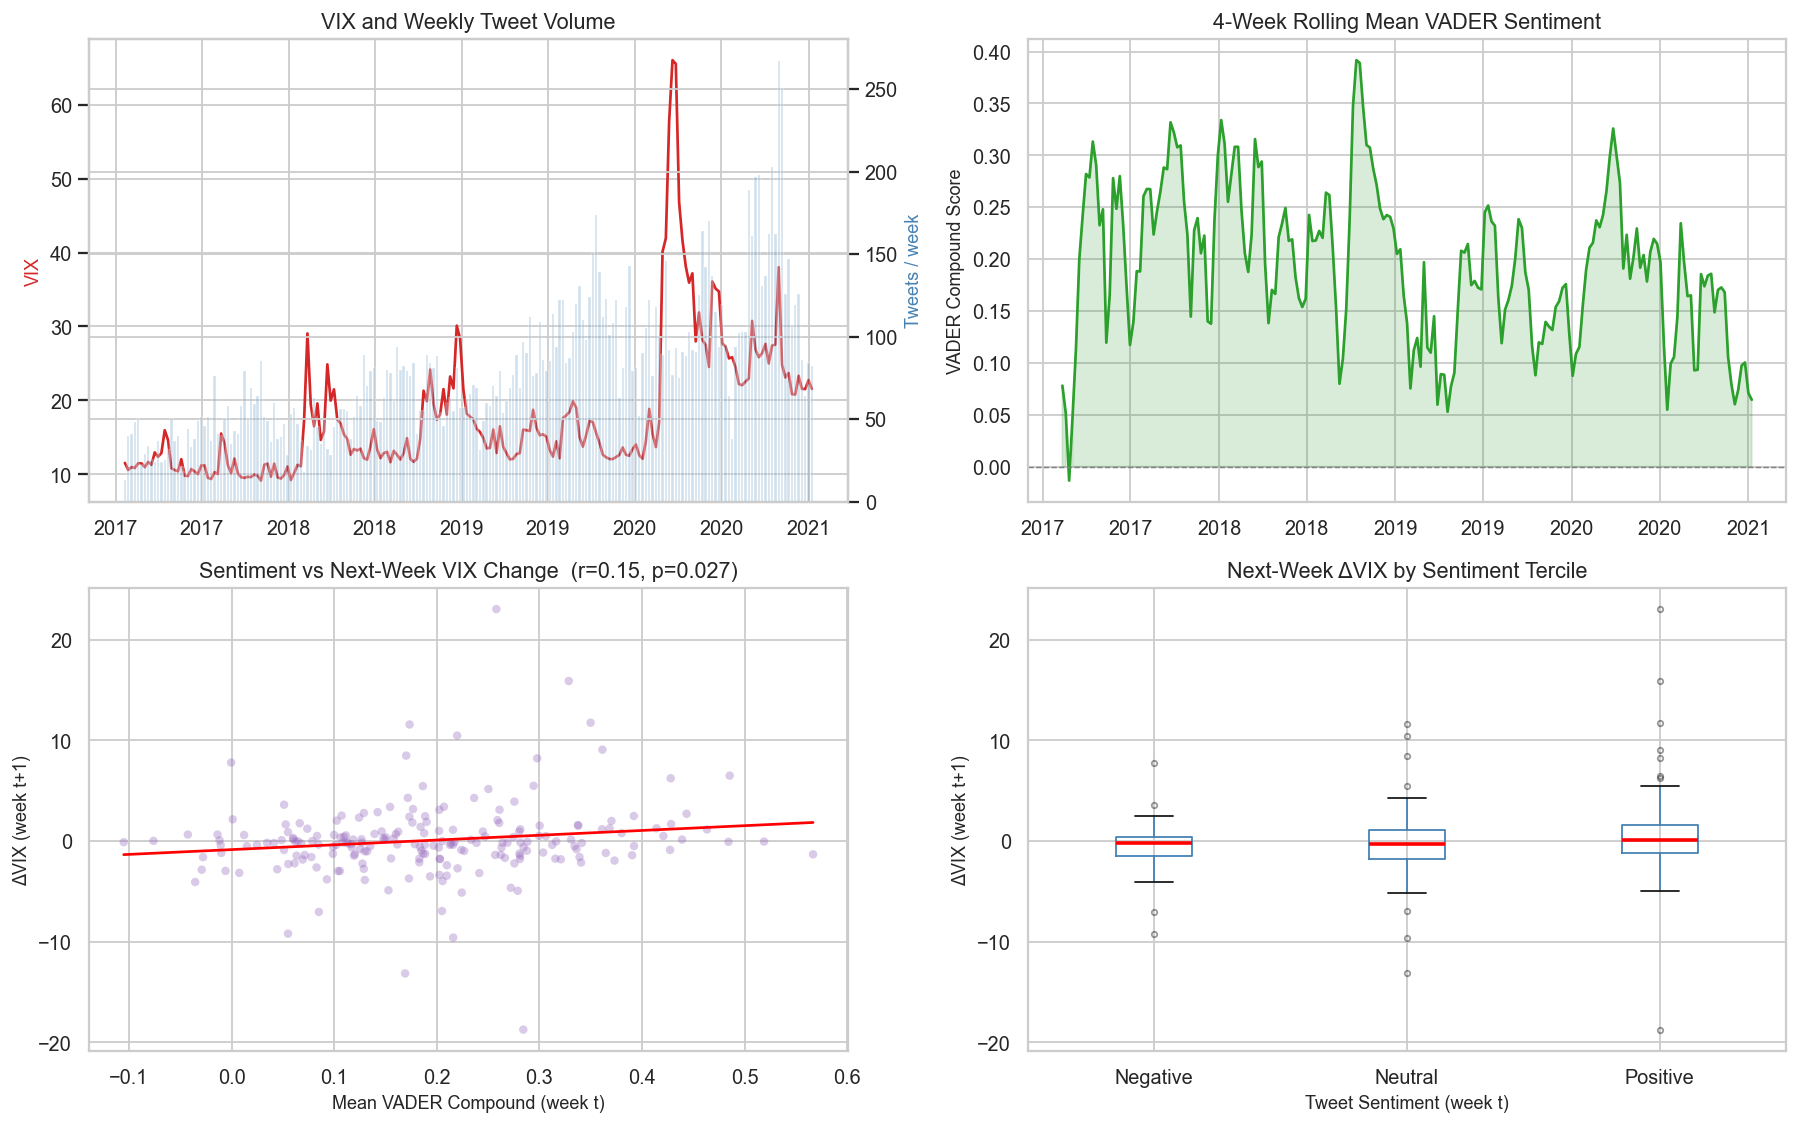

Saved: eda_plots.png


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Trump Tweets & Market Volatility — EDA", fontsize=14, fontweight='bold')

# ── (a) VIX + tweet volume over time ──
ax = axes[0, 0]
ax2 = ax.twinx()
ax.plot(master['week_end'], master['vix'], color='#d62728', lw=1.5, label='VIX')
ax2.bar(master['week_end'], master['tweet_count'], alpha=0.25, color='steelblue', width=5, label='Tweets/week')
ax.set_title('VIX and Weekly Tweet Volume')
ax.set_ylabel('VIX', color='#d62728')
ax2.set_ylabel('Tweets / week', color='steelblue')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# ── (b) VADER sentiment (4-week rolling) ──
ax = axes[0, 1]
roll = master.set_index('week_end')['mean_vader'].rolling(4).mean()
ax.plot(master['week_end'], roll.values, color='#2ca02c', lw=1.5)
ax.axhline(0, linestyle='--', color='grey', lw=0.8)
ax.fill_between(master['week_end'], roll.values, 0,
                where=(roll.values < 0), alpha=0.15, color='red')
ax.fill_between(master['week_end'], roll.values, 0,
                where=(roll.values > 0), alpha=0.15, color='green')
ax.set_title('4-Week Rolling Mean VADER Sentiment')
ax.set_ylabel('VADER Compound Score')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# ── (c) Scatter: VADER vs next-week ΔVIX ──
ax = axes[1, 0]
ax.scatter(master['mean_vader'], master['delta_vix_next'],
           alpha=0.35, s=22, color='#9467bd', edgecolors='none')
m, b, r, p, _ = stats.linregress(
    master[['mean_vader','delta_vix_next']].dropna()['mean_vader'],
    master[['mean_vader','delta_vix_next']].dropna()['delta_vix_next'])
xl = np.linspace(master['mean_vader'].min(), master['mean_vader'].max(), 100)
ax.plot(xl, m*xl+b, color='red', lw=1.5)
ax.set_xlabel('Mean VADER Compound (week t)')
ax.set_ylabel('ΔVIX (week t+1)')
ax.set_title(f'Sentiment vs Next-Week VIX Change  (r={r:.2f}, p={p:.3f})')

# ── (d) VIX distribution by sentiment tercile ──
ax = axes[1, 1]
master['sentiment_bin'] = pd.qcut(master['mean_vader'], 3,
                                   labels=['Negative','Neutral','Positive'])
master.boxplot(column='delta_vix_next', by='sentiment_bin', ax=ax,
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red', lw=2),
               whiskerprops=dict(color='steelblue'),
               flierprops=dict(marker='o', markersize=3, alpha=0.4))
ax.set_title('Next-Week ΔVIX by Sentiment Tercile')
ax.set_xlabel('Tweet Sentiment (week t)')
ax.set_ylabel('ΔVIX (week t+1)')
plt.suptitle('')  # remove auto boxplot title

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: eda_plots.png")


## 10. Correlation Table — Tweet Features vs VIX

Correlation Matrix
                  tweet_count  mean_vader  frac_negative  mean_frac_caps  mean_exclamation  mean_retweets    vix  delta_vix  delta_vix_next    epu
tweet_count             1.000      -0.206         -0.023           0.203             0.390          0.225  0.406     -0.000           0.003  0.536
mean_vader             -0.206       1.000         -0.824          -0.045             0.036         -0.247  0.021      0.079           0.154 -0.122
frac_negative          -0.023      -0.824          1.000          -0.113             0.070          0.026 -0.174     -0.064          -0.134 -0.129
mean_frac_caps          0.203      -0.045         -0.113           1.000             0.213          0.374  0.293      0.095           0.099  0.317
mean_exclamation        0.390       0.036          0.070           0.213             1.000          0.276  0.318     -0.020          -0.048  0.387
mean_retweets           0.225      -0.247          0.026           0.374             0.276         

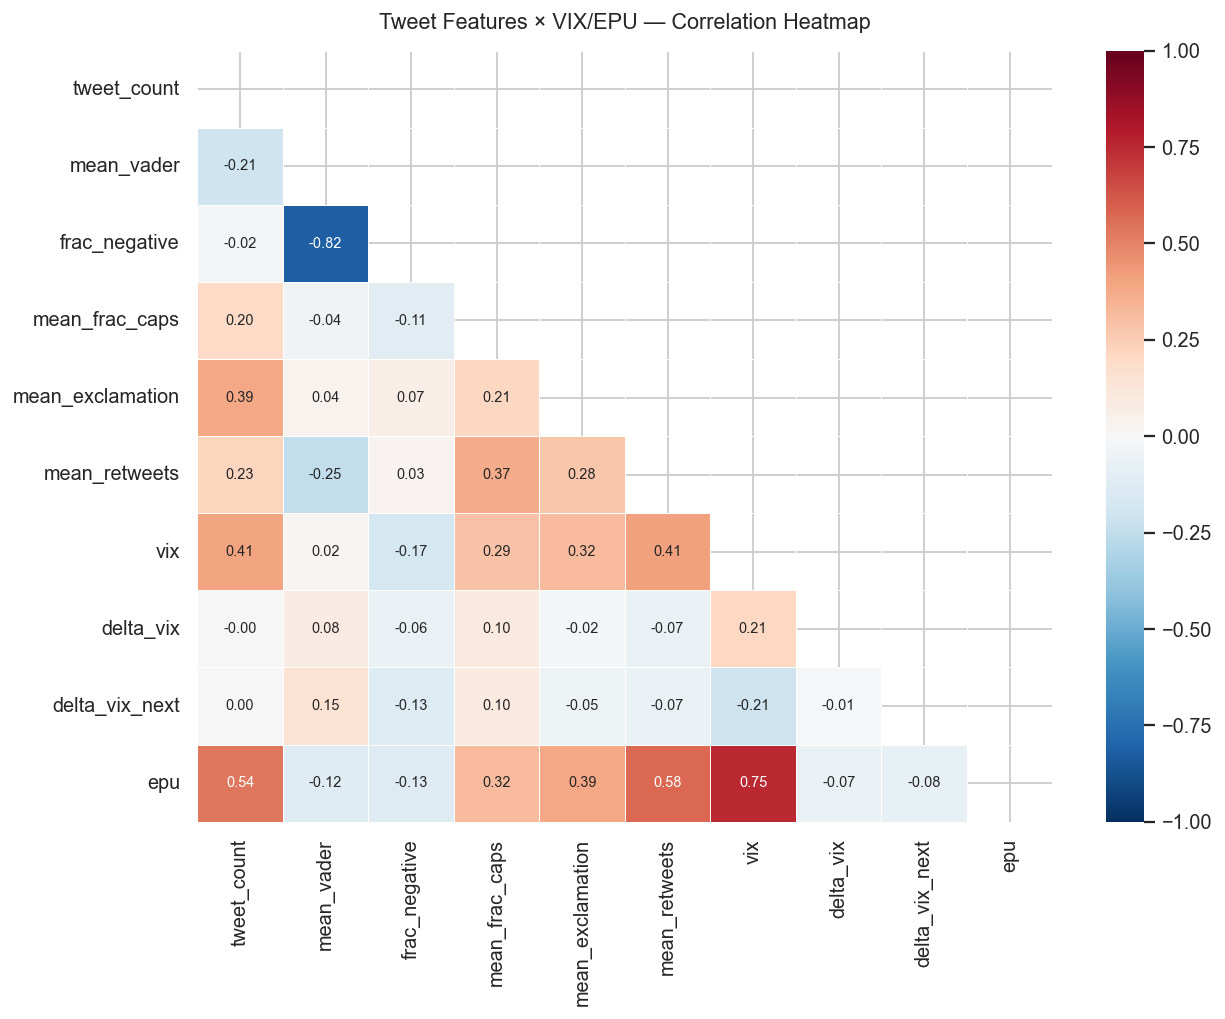

Saved: correlation_heatmap.png


In [17]:
corr_cols = ['tweet_count','mean_vader','frac_negative','mean_frac_caps',
             'mean_exclamation','mean_retweets','vix','delta_vix','delta_vix_next']
if 'epu' in master.columns:
    corr_cols.append('epu')

corr = master[corr_cols].corr().round(3)
print("Correlation Matrix")
print(corr.to_string())

# Heatmap
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Tweet Features × VIX/EPU — Correlation Heatmap', pad=12)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: correlation_heatmap.png")


## 11. Save Master Dataset (for later notebooks)

In [18]:
master.to_csv('master_weekly.csv', index=False)
print(f"Saved master_weekly.csv — {len(master)} rows × {master.shape[1]} cols")
print("Columns:", list(master.columns))


Saved master_weekly.csv — 208 rows × 25 cols
Columns: ['week_end', 'tweet_count', 'mean_vader', 'std_vader', 'mean_vader_neg', 'mean_vader_pos', 'frac_negative', 'frac_positive', 'mean_frac_caps', 'mean_exclamation', 'mean_tweet_len', 'mean_retweets', 'mean_favorites', 'n_hashtags', 'vix', 'vix_lag1', 'delta_vix', 'delta_vix_next', 'epu', 'delta_epu', 'fedfunds', 'unrate', 'sp500', 'sp500_ret', 'sentiment_bin']
